In [22]:
from typing_extensions import TypedDict, Literal, Annotated
from typing import List
from langgraph.types import Send
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from pydantic import BaseModel
from operator import add

llm = init_chat_model("openai:gpt-4o-mini")
greeting_llm = llm.invoke("준비 됬니?")

print(greeting_llm.content)

네, 준비되었습니다! 어떻게 도와드릴까요?


In [23]:
class State(TypedDict) :
    document : str
    final_summary : str
    summaries : Annotated[list[dict], add]          # dictionary 배열


In [24]:
# 문장 요약 작업자
def worker_summarize_paragraph(args) : 
    paragraph = args["paragraph"]
    index = args["index"]

    res = llm.invoke(
        f"Write a 3-sentence summary for this paragraph : {paragraph}"
    )

    return {
        "summaries" : [
            {
                "summary" : res.content,
                "index" : index
            }
        ]
    }

# worker 노드 실행자
def dispatch_summarizers(state : State) : 
    chunks = state["document"].split("\n\n")            # 줄바꿈 단위로 장문 쪼개기

    return[
        Send("worker_summarize_paragraph", {"paragraph" : chunk, "index" : index})
        for index, chunk in enumerate(chunks)
    ]

# 최종 요약
def final_summary(state : State):
    res = llm.invoke(
        f"Using the following summaries, give me a final one {state["summaries"]}"
    )    

    return {
        "final_summary" : res.content
    }


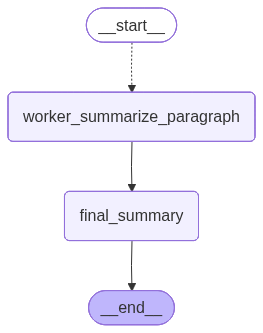

In [25]:

graph_builder = StateGraph(State)

graph_builder.add_node("worker_summarize_paragraph", worker_summarize_paragraph)
graph_builder.add_node("final_summary", final_summary)

# 필요한만큼 worker_summarize_paragraph 노드 실행
graph_builder.add_conditional_edges(START, dispatch_summarizers, ["worker_summarize_paragraph"])
graph_builder.add_edge("worker_summarize_paragraph", "final_summary")
graph_builder.add_edge("final_summary", END)

graph = graph_builder.compile()

graph


In [26]:
with open("fed_transcript.md", "r", encoding="utf-8") as file:
    document = file.read()

for chunk in graph.stream({"document" : document}, stream_mode="updates"):
    print(chunk, "\n")



{'worker_summarize_paragraph': {'summaries': [{'summary': 'Individual forecasts carry inherent uncertainty and do not represent a collective decision or plan. They reflect a range of potential outcomes rather than a predetermined trajectory. Consequently, policy remains flexible and adaptable to changing circumstances.', 'index': 21}]}} 

{'worker_summarize_paragraph': {'summaries': [{'summary': 'The unemployment rate in the labor market rose slightly to 4.3 percent in August. Despite this increase, the rate has remained stable over the past year. Overall, the unemployment level continues to be relatively low.', 'index': 5}]}} 

{'worker_summarize_paragraph': {'summaries': [{'summary': 'The current moderation and growth can be primarily attributed to a slowdown in consumer spending. This decline in spending is influencing various economic indicators. As a result, overall economic activity is experiencing a noticeable slowdown.', 'index': 2}]}} 

{'worker_summarize_paragraph': {'summari